# **03A: ARIMA Forecasting Model**

**Project:** Multi-Disease Outbreak Forecasting with Temporal Deep Learning

**Research Question:** Can we accurately forecast short-term disease incidence across Canadian provinces, and how does a classical time-series baseline such as ARIMA compare against a deep learning model like LSTM in notebook `03B`?

**End User:** Provincial and federal public health agencies (e.g., PHAC), epidemiologists, health system planners.

This notebook implements the **classical baseline model** for the forecasting pipeline using **ARIMA**. It uses the finalized modeling dataset from notebook `01`, prepares weekly province x disease time series for the three diseases (**influenza, measles, pertussis**).
In the dataset, pertussis appears under the label `whooping-cough`, and is used during filtering to stay consistent with the cleaned modeling dataset.

The notebook tunes a small ARIMA order grid on the validation period, selects the best ARIMA order for each disease, and evaluates the final baseline on the test period. These outputs are saved for comparison with the LSTM model.

**Inputs (from notebook `01`):**
- `data/processed/final_modeling_dataset.csv`

**Outputs from this notebook:**

- `reports/tables/arima_order_search.csv`
- `reports/tables/arima_best_orders.csv`
- `reports/tables/arima_test_results.csv`
- `reports/tables/arima_test_summary.csv`
- `reports/tables/arima_test_forecasts.csv`
- `reports/figures/arima_test_forecast_<disease>_<province>.png`

## 1. Setup

Configure the repository path and working environment.

In [1]:
import os

REPO_DIR = "/Users/deansimmer/git/AAI-590-capstone-canadian-health"
print(f"Using repository at: {REPO_DIR}")

Using repository at: /Users/deansimmer/git/AAI-590-capstone-canadian-health


In [2]:
# Create output folders used in this notebook
MODEL_DIR = os.path.join(REPO_DIR, "models", "arima_baseline")
FIGURES_DIR = os.path.join(REPO_DIR, "reports", "figures")
TABLES_DIR = os.path.join(REPO_DIR, "reports", "tables")

for folder in [MODEL_DIR, TABLES_DIR, FIGURES_DIR]:
  os.makedirs(folder, exist_ok=True)
  print(f"Created folder: {folder}")

Created folder: /Users/deansimmer/git/AAI-590-capstone-canadian-health/models/arima_baseline
Created folder: /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/tables
Created folder: /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/figures


## 2. Imports & Reproducibility

In [3]:
import json
import random
import warnings
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("default")

print(f"Set to {SEED}.")

Set to 42.


## 3. Hyperparameters & Configuration

Choices are kept simple because this notebook is meant as a classical baseline that will be compared against the LSTM model in notebook `03B`.

**Disease scope**
- `influenza`
- `measles`
- `whooping-cough` (pertussis)

**Baseline logic**
- Use `cases_per_100k` as the forecast target, which matches the normalized target used in notebook `01` and supports cleaner comparison across provinces.
- Tune a small ARIMA order grid on the validation split.
- Select the best order **per disease** using mean validation RMSE across retained province series.

In [4]:
# Split boundaries
TRAIN_CUTOFF = pd.Timestamp("1986-01-01")
VAL_CUTOFF = pd.Timestamp("2004-01-01")

# Disease focus
KEY_DISEASES = ["influenza", "measles", "whooping-cough"]

# Keep only province x disease series with enough weekly coverage
MIN_COVERAGE = 0.70

# ARIMA grid for baseline tuning
ARIMA_GRID = [
    (1, 0, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
]

# Forecast length for future outlook
FORECAST = 8

print("Configuration is loaded.")
print(f"Focus diseases     : {KEY_DISEASES}")
print(f"Train cutoff       : {TRAIN_CUTOFF.date()}")
print(f"Validation cutoff  : {VAL_CUTOFF.date()}")
print(f"Candidate orders   : {ARIMA_GRID}")

Configuration is loaded.
Focus diseases     : ['influenza', 'measles', 'whooping-cough']
Train cutoff       : 1986-01-01
Validation cutoff  : 2004-01-01
Candidate orders   : [(1, 0, 0), (0, 1, 1), (1, 1, 1), (2, 1, 1), (1, 1, 2)]


## 4. Load Final Modeling Dataset

In [5]:
PROCESSED_DIR = os.path.join(REPO_DIR, "data", "processed")
MODEL_DATA_PATH = os.path.join(PROCESSED_DIR, "final_modeling_dataset.csv")

if not os.path.exists(MODEL_DATA_PATH):
    raise FileNotFoundError(
        f"final_modeling_dataset.csv not found at {MODEL_DATA_PATH}.\n"
        "Run notebook 01 first."
    )

arima_model_df = pd.read_csv(
    MODEL_DATA_PATH,
    parse_dates=["period_start_date", "period_end_date", "period_mid_date"]
)

print(f"Loaded dataset from: {MODEL_DATA_PATH}")
print(f"Shape: {arima_model_df.shape}")
print("\nColumns: ")
print(arima_model_df.columns.tolist())

Loaded dataset from: /Users/deansimmer/git/AAI-590-capstone-canadian-health/data/processed/final_modeling_dataset.csv
Shape: (934010, 15)

Columns: 
['iso_3166', 'iso_3166_2', 'period_start_date', 'period_end_date', 'period_mid_date', 'disease', 'basal_disease', 'cases_this_period', 'location', 'location_type', 'time_scale', 'days_this_period', 'population', 'record_origin', 'split']


In [6]:
# Keep only the 3 diseases and weekly records
focus_df = arima_model_df[
    (arima_model_df["disease"].isin(KEY_DISEASES)) &
    (arima_model_df["time_scale"] == "wk")
].copy()

# Convert numeric columns
focus_df["cases_this_period"] = pd.to_numeric(
    focus_df["cases_this_period"], errors="coerce"
)
focus_df["population"] = pd.to_numeric(
    focus_df["population"], errors="coerce"
)

# Drop rows missing key fields
focus_df = focus_df.dropna(
    subset=["cases_this_period", "population", "iso_3166_2", "period_start_date"]
).copy()

# Create target rate
focus_df["cases_per_100k"] = (
    focus_df["cases_this_period"] / focus_df["population"]
) * 100000

print(f"Shape: {focus_df.shape}")
print("\nRecords per disease:")
print(focus_df["disease"].value_counts().sort_index().to_string())

print("\nProvince x disease pairs:")
print(
    focus_df.groupby(["disease", "iso_3166_2"])
    .size()
    .reset_index(name="n_rows")
    .shape[0]
)

Shape: (46120, 16)

Records per disease:
disease
influenza          4900
measles           11163
whooping-cough    30057

Province x disease pairs:
34


## 5. Rebuild Complete Weekly Province x Disease Series

In [7]:
full_min = focus_df["period_start_date"].min()
full_max = focus_df["period_start_date"].max()
master_weeks = pd.date_range(start=full_min, end=full_max, freq="W-SUN")

print(f"Weekly range : {full_min.date()} - {full_max.date()}")
print(f"Total weekly points : {len(master_weeks):,}")

Weekly range : 1923-12-30 - 2021-12-26
Total weekly points : 5,114


In [8]:
series_dict = {}
cov_rows = []
excluded_rows = []

for (disease, province), group in focus_df.groupby(["disease", "iso_3166_2"]):
    raw_series = (
        group.sort_values("period_start_date")
             .set_index("period_start_date")["cases_per_100k"]
    )

    series = raw_series.reindex(master_weeks)
    coverage = series.notna().mean()

    if coverage < MIN_COVERAGE:
        excluded_rows.append({
            "disease": disease,
            "province": province,
            "coverage": round(float(coverage), 3)
        })
        continue

    # Fill gaps, then fill the rest with missing values with 0
    series = series.interpolate(method="linear", limit=4)
    series = series.fillna(0.0)

    series_dict[(disease, province)] = series

    cov_rows.append({
        "disease": disease,
        "province": province,
        "coverage": round(float(coverage), 3),
        "n_weeks": int(len(series)),
        "mean_rate": float(series.mean()),
        "max_rate": float(series.max()),
    })

coverage_df = pd.DataFrame(cov_rows).sort_values(["disease", "province"]).reset_index(drop=True)

print(f"Series retained  : {len(series_dict)}")
print(f"Series excluded  : {len(excluded_rows)}")

if excluded_rows:
    print("\nExcluded pairs:")
    print(pd.DataFrame(excluded_rows).sort_values("coverage").to_string(index=False))


Series retained  : 4
Series excluded  : 30

Excluded pairs:
       disease province  coverage
     influenza    CA-AB     0.000
     influenza    CA-NL     0.000
     influenza    CA-NB     0.010
     influenza    CA-BC     0.031
     influenza    CA-MB     0.031
     influenza    CA-NS     0.031
     influenza    CA-PE     0.031
     influenza    CA-QC     0.031
     influenza    CA-SK     0.031
       measles    CA-PE     0.054
       measles    CA-NB     0.091
       measles    CA-YT     0.093
       measles    CA-NT     0.093
       measles    CA-SK     0.099
       measles    CA-BC     0.117
       measles    CA-NS     0.119
       measles    CA-NL     0.120
       measles    CA-QC     0.127
       measles    CA-MB     0.128
whooping-cough    CA-NT     0.191
whooping-cough    CA-YT     0.191
whooping-cough    CA-NL     0.289
       measles    CA-AB     0.328
whooping-cough    CA-BC     0.456
whooping-cough    CA-MB     0.457
whooping-cough    CA-QC     0.457
whooping-cough    CA-P

Sample series: ('measles', 'CA-ON')
Length      : 5,114
Zeros       : 1,998
Min / Max   : 0.0000 / 53.7026
Date range  : 1923-12-30 → 2021-12-26


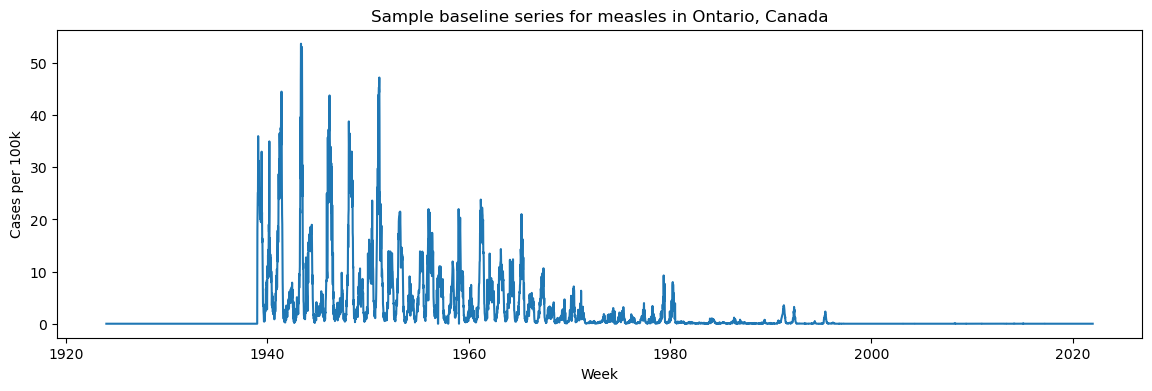

In [9]:
# Preview
sample_key = ("measles", "CA-ON")

if sample_key in series_dict:
    sample_series = series_dict[sample_key]
    print(f"Sample series: {sample_key}")
    print(f"Length      : {len(sample_series):,}")
    print(f"Zeros       : {(sample_series == 0).sum():,}")
    print(f"Min / Max   : {sample_series.min():.4f} / {sample_series.max():.4f}")
    print(f"Date range  : {sample_series.index.min().date()} → {sample_series.index.max().date()}")

    plt.figure(figsize=(14, 4))
    plt.plot(sample_series.index, sample_series.values)
    plt.title("Sample baseline series for measles in Ontario, Canada")
    plt.xlabel("Week")
    plt.ylabel("Cases per 100k")
    plt.show()
else:
    print("Not found.")


## 6. Check Existing Train/Validation/Test Split

This portion uses the existing split column created and validated in notebook `01`. To keep the baseline ARIMA workflow consistent with the rest of the project, train/val/test are not redefined here.

In [10]:
split_check_df = (
    focus_df.groupby(["disease", "split"])
    .size()
    .unstack(fill_value=0)
)
print("Records by disease and split: ")
display(split_check_df)

Records by disease and split: 


split,test,train,validation
disease,,,
influenza,932,3107,861
measles,1611,8416,1136
whooping-cough,1766,27151,1140


## 7. ARIMA Helper Functions

In [11]:
# Calculate RMSE
def calc_rmse(y_true, y_pred):
  return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# Fit ARIMA and forecast
def fit_arima(series, steps, order):
  fitted_model = ARIMA(series, order=order).fit()
  forecast = fitted_model.forecast(steps=steps)
  return fitted_model, np.asarray(forecast, dtype=float)

# Train ARIMA, forecast the test period, and calculate metrics
def evaluate_series(train_series, test_series, order):
  fitted_model, forecast = fit_arima(
      series=train_series,
      steps=len(test_series),
      order=order
  )

  actual = test_series.values.astype(float)

  return {
      "rmse": calc_rmse(actual, forecast),
      "mae": float(mean_absolute_error(actual, forecast)),
      "aic": float(fitted_model.aic),
      "bic": float(fitted_model.bic),
      "forecast": forecast,
  }

# Create forecast table
def create_forecast_df(disease, province, dates, actual, pred, split_name, order):
  return pd.DataFrame({
      "disease": disease,
      "province": province,
      "split": split_name,
      "date": pd.to_datetime(dates),
      "actual_cases_per_100k": np.asarray(actual, dtype=float),
      "pred_cases_per_100k": np.asarray(pred, dtype=float),
      "arima_order": str(order),
  })

# Turn an order string to tuple
def parse_order(order_t):
  return tuple(ast.literal_eval(order_t))

## 8. Tune ARIMA

In [12]:
# Organize retained series by disease
disease_series = {}

for (disease, province), s in series_dict.items():
    if disease not in disease_series:
        disease_series[disease] = {}

    disease_series[disease][province] = s

print(f"Total diseases retained: {len(disease_series)}")
for disease, provinces in disease_series.items():
    print(f"  {disease:<16} {len(provinces)} series")

Total diseases retained: 3
  influenza        1 series
  measles          1 series
  whooping-cough   2 series


In [13]:
search_rows = []

for disease, provinces in disease_series.items():
    print(f"\nTuning ARIMA for {disease}")

    for order in ARIMA_GRID:
        rmse_list = []
        mae_list = []
        aic_list = []
        bic_list = []
        n_scored = 0

        for province, full_series in provinces.items():
            train_series = full_series[full_series.index < TRAIN_CUTOFF]
            val_series = full_series[
                (full_series.index >= TRAIN_CUTOFF) &
                (full_series.index < VAL_CUTOFF)
            ]

            if len(train_series) < 20 or len(val_series) == 0:
                continue

            try:
                scores = evaluate_series(train_series, val_series, order)

                rmse_list.append(scores["rmse"])
                mae_list.append(scores["mae"])
                aic_list.append(scores["aic"])
                bic_list.append(scores["bic"])
                n_scored += 1

            except Exception as e:
                print(f"Failed: {disease} | {province} | {order} | {e}")
                continue

        print(
            f"Order {order} | "
            f"mean val RMSE = {np.mean(rmse_list) if rmse_list else np.nan:.4f} | "
            f"mean val MAE = {np.mean(mae_list) if mae_list else np.nan:.4f} | "
            f"series scored = {n_scored}"
        )

        search_rows.append({
            "disease": disease,
            "order": str(order),
            "mean_val_rmse": np.mean(rmse_list) if rmse_list else np.nan,
            "mean_val_mae": np.mean(mae_list) if mae_list else np.nan,
            "mean_aic": np.mean(aic_list) if aic_list else np.nan,
            "mean_bic": np.mean(bic_list) if bic_list else np.nan,
            "n_series_scored": n_scored,
        })

search_df = pd.DataFrame(search_rows)
search_df = search_df.sort_values(["disease", "mean_val_rmse"]).reset_index(drop=True)

print("\nValidation search summary:")
display(search_df)


Tuning ARIMA for influenza
Order (1, 0, 0) | mean val RMSE = 2.0851 | mean val MAE = 1.2402 | series scored = 1
Order (0, 1, 1) | mean val RMSE = 2.4097 | mean val MAE = 1.8469 | series scored = 1
Order (1, 1, 1) | mean val RMSE = 2.6540 | mean val MAE = 2.1930 | series scored = 1
Order (2, 1, 1) | mean val RMSE = 2.6249 | mean val MAE = 2.1535 | series scored = 1
Order (1, 1, 2) | mean val RMSE = 2.6012 | mean val MAE = 2.1207 | series scored = 1

Tuning ARIMA for measles
Order (1, 0, 0) | mean val RMSE = 3.5485 | mean val MAE = 3.5053 | series scored = 1
Order (0, 1, 1) | mean val RMSE = 0.4470 | mean val MAE = 0.1470 | series scored = 1
Order (1, 1, 1) | mean val RMSE = 0.4471 | mean val MAE = 0.1469 | series scored = 1
Order (2, 1, 1) | mean val RMSE = 0.4473 | mean val MAE = 0.1468 | series scored = 1
Order (1, 1, 2) | mean val RMSE = 0.4574 | mean val MAE = 0.1565 | series scored = 1

Tuning ARIMA for whooping-cough
Order (1, 0, 0) | mean val RMSE = 0.9527 | mean val MAE = 0.942

,disease,order,mean_val_rmse,mean_val_mae,mean_aic,mean_bic,n_series_scored
0,influenza,"(1, 0, 0)",2.085083,1.240167,16949.782866,16968.029145,1
1,influenza,"(0, 1, 1)",2.409720,1.846867,17256.680663,17268.844232,1
2,influenza,"(1, 1, 2)",2.601152,2.120676,16917.763199,16942.090336,1
3,influenza,"(2, 1, 1)",2.624854,2.153517,16925.589236,16949.916372,1
4,influenza,"(1, 1, 1)",2.653996,2.193042,16938.257220,16956.502573,1
5,measles,"(0, 1, 1)",0.447032,0.146951,14424.217451,14436.381019,1
6,measles,"(1, 1, 1)",0.447098,0.146922,14345.994261,14364.239614,1
7,measles,"(2, 1, 1)",0.447338,0.146831,14326.064309,14350.391446,1
8,measles,"(1, 1, 2)",0.457450,0.156507,14175.719115,14200.046252,1
9,measles,"(1, 0, 0)",3.548522,3.505308,14765.353687,14783.599967,1


## 9. Select the Best ARIMA Order by Disease

In [14]:
# Pick the best ARIMA order
best_order = (
    search_df.sort_values(["disease", "mean_val_rmse"])
    .groupby("disease", as_index=False)
    .first()
)

print("Best Order: ")
display(best_order[["disease", "order", "mean_val_rmse", "mean_val_mae", "n_series_scored"]])

Best Order: 


,disease,order,mean_val_rmse,mean_val_mae,n_series_scored
0,influenza,"(1, 0, 0)",2.085083,1.240167,1
1,measles,"(0, 1, 1)",0.447032,0.146951,1
2,whooping-cough,"(0, 1, 1)",0.217569,0.170562,2


## 10. Create a Table for Best Orders

In [15]:
# Build directory
best_order_map = {}

for _, row in best_order.iterrows():
  best_order_map[row["disease"]] = parse_order(row["order"])

print("Best order map: ")
print(best_order_map)

Best order map: 
{'influenza': (1, 0, 0), 'measles': (0, 1, 1), 'whooping-cough': (0, 1, 1)}


## 11. Evaluate the Final ARIMA Baseline on the Test Set

In [16]:
test_rows = []
test_forecasts = []

for disease, provinces in disease_series.items():
    order = best_order_map[disease]
    print(f"\nTesting ARIMA {disease} with {order}")

    for province, full_series in provinces.items():
        train_series = full_series[full_series.index < TRAIN_CUTOFF]
        val_series = full_series[
            (full_series.index >= TRAIN_CUTOFF) &
            (full_series.index < VAL_CUTOFF)
        ]
        test_series = full_series[full_series.index >= VAL_CUTOFF]

        if len(train_series) < 20 or len(test_series) == 0:
            continue

        # Combine train/val prior to final test forecast
        history_series = pd.concat([train_series, val_series])

        try:
            scores = evaluate_series(history_series, test_series, order)

            test_rows.append({
                "disease": disease,
                "province": province,
                "order": str(order),
                "test_rmse": scores["rmse"],
                "test_mae": scores["mae"],
                "aic": scores["aic"],
                "bic": scores["bic"],
                "n_test_weeks": len(test_series),
            })

            forecast_df = create_forecast_df(
                disease=disease,
                province=province,
                dates=test_series.index,
                actual=test_series.values,
                pred=scores["forecast"],
                split_name="test",
                order=order,
            )
            test_forecasts.append(forecast_df)

        except Exception as e:
            print(f"Did not work: {disease} | {province} | {order} | {e}")
            continue

test_results_df = pd.DataFrame(test_rows)
test_forecasts_df = pd.concat(test_forecasts, ignore_index=True)

print("Test shape:", test_results_df.shape)
display(test_results_df.head())


Testing ARIMA influenza with (1, 0, 0)

Testing ARIMA measles with (0, 1, 1)

Testing ARIMA whooping-cough with (0, 1, 1)
Test shape: (4, 8)


,disease,province,order,test_rmse,test_mae,aic,bic,n_test_weeks
0,influenza,CA-ON,"(1, 0, 0)",2.233511,1.412476,21010.028072,21029.038681,939
1,measles,CA-ON,"(0, 1, 1)",0.006501,0.001978,17551.099156,17563.772416,939
2,whooping-cough,CA-AB,"(0, 1, 1)",0.269657,0.236868,11008.154262,11020.827522,939
3,whooping-cough,CA-ON,"(0, 1, 1)",0.067736,0.047465,6632.471073,6645.144333,939


## 12. Summarize Test Performance

In [17]:
test_sum_df = (
    test_results_df
    .groupby("disease", as_index=False)[["test_mae", "test_rmse", "aic", "bic"]]
    .mean()
    .round(4)
    .rename(columns={
        "test_mae": "mae",
        "test_rmse": "rmse"
    })
)

print("ARIMA test summary:")
display(test_sum_df)

ARIMA test summary:


,disease,mae,rmse,aic,bic
0,influenza,1.4125,2.2335,21010.0281,21029.0387
1,measles,0.0020,0.0065,17551.0992,17563.7724
2,whooping-cough,0.1422,0.1687,8820.3127,8832.9859


## 13. Save Final ARIMA Outputs

In [18]:
print(test_results_df.shape)
print(test_results_df.columns)
display(test_results_df.head(10))
print(sorted(test_results_df["disease"].unique()))

(4, 8)
Index(['disease', 'province', 'order', 'test_rmse', 'test_mae', 'aic', 'bic',
       'n_test_weeks'],
      dtype='object')


,disease,province,order,test_rmse,test_mae,aic,bic,n_test_weeks
0,influenza,CA-ON,"(1, 0, 0)",2.233511,1.412476,21010.028072,21029.038681,939
1,measles,CA-ON,"(0, 1, 1)",0.006501,0.001978,17551.099156,17563.772416,939
2,whooping-cough,CA-AB,"(0, 1, 1)",0.269657,0.236868,11008.154262,11020.827522,939
3,whooping-cough,CA-ON,"(0, 1, 1)",0.067736,0.047465,6632.471073,6645.144333,939


['influenza', 'measles', 'whooping-cough']


In [19]:
REPO_TABLES = os.path.join(REPO_DIR, "reports", "tables")
os.makedirs(REPO_TABLES, exist_ok=True)

test_results_df.to_csv(os.path.join(REPO_TABLES, "arima_test_results.csv"), index=False)
test_sum_df.to_csv(os.path.join(REPO_TABLES, "arima_test_summary.csv"), index=False)
test_forecasts_df.to_csv(os.path.join(REPO_TABLES, "arima_test_forecasts.csv"), index=False)

print("Saved the ARIMA evaluation outputs.")

# Check
repo_check = pd.read_csv(os.path.join(REPO_TABLES, "arima_test_results.csv"))
print("\nReloaded arima_test_results.csv from repo path:")
print("Shape:", repo_check.shape)
print("Columns:", list(repo_check.columns))
display(repo_check.head())
print("Diseases:", sorted(repo_check["disease"].unique()))

Saved the ARIMA evaluation outputs.

Reloaded arima_test_results.csv from repo path:
Shape: (4, 8)
Columns: ['disease', 'province', 'order', 'test_rmse', 'test_mae', 'aic', 'bic', 'n_test_weeks']


,disease,province,order,test_rmse,test_mae,aic,bic,n_test_weeks
0,influenza,CA-ON,"(1, 0, 0)",2.233511,1.412476,21010.028072,21029.038681,939
1,measles,CA-ON,"(0, 1, 1)",0.006501,0.001978,17551.099156,17563.772416,939
2,whooping-cough,CA-AB,"(0, 1, 1)",0.269657,0.236868,11008.154262,11020.827522,939
3,whooping-cough,CA-ON,"(0, 1, 1)",0.067736,0.047465,6632.471073,6645.144333,939


Diseases: ['influenza', 'measles', 'whooping-cough']


## 14. Plot Example Test Forecasts

Saved:  /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/figures/arima_test_forecast_influenza_CA-ON.png


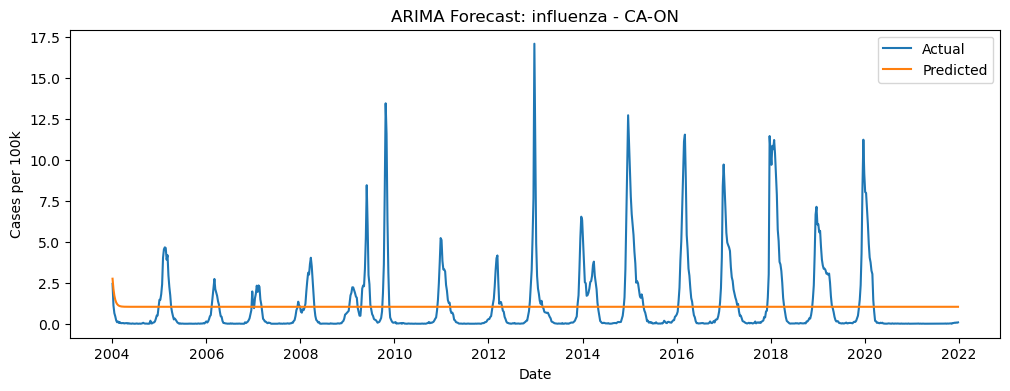

Saved:  /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/figures/arima_test_forecast_measles_CA-ON.png


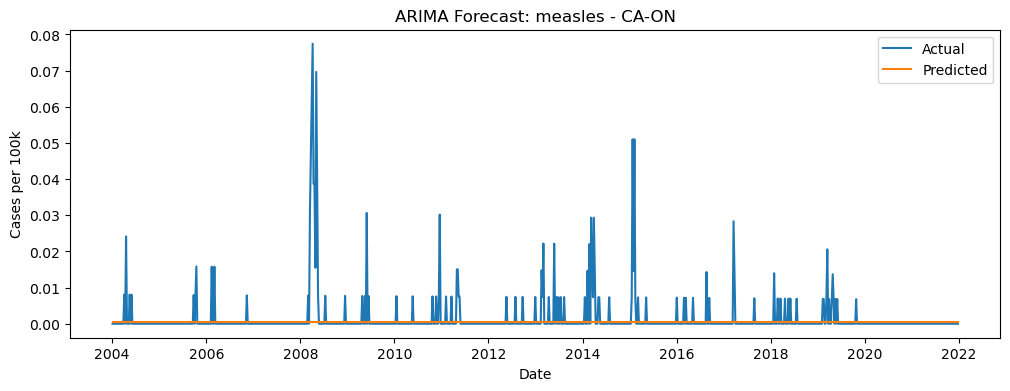

Saved:  /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/figures/arima_test_forecast_whooping-cough_CA-AB.png


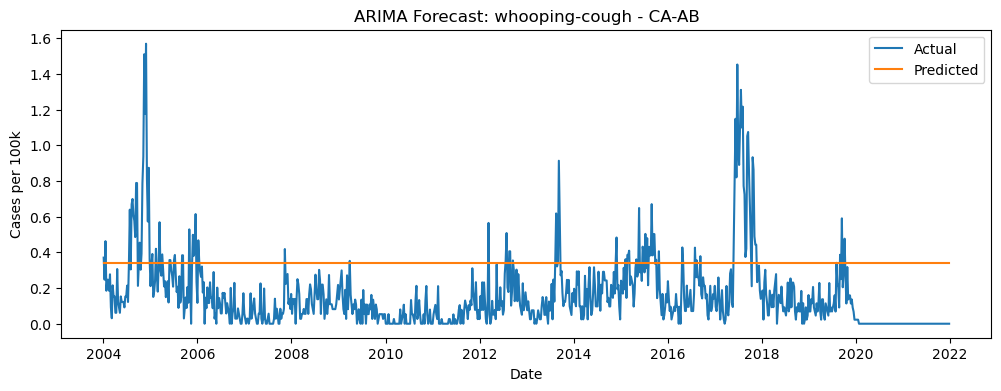

In [20]:
# Plot one example province per disease
for disease in sorted(test_forecasts_df["disease"].unique()):
    disease_df = test_forecasts_df[test_forecasts_df["disease"] == disease].copy()
    f_province = sorted(disease_df["province"].unique())[0]
    plot_df = disease_df[disease_df["province"] == f_province].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["date"], plot_df["actual_cases_per_100k"], label="Actual")
    plt.plot(plot_df["date"], plot_df["pred_cases_per_100k"], label="Predicted")
    plt.xlabel("Date")
    plt.ylabel("Cases per 100k")
    plt.title(f"ARIMA Forecast: {disease} - {f_province}")
    plt.legend()

    fig_path = os.path.join(FIGURES_DIR, f"arima_test_forecast_{disease}_{f_province}.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print("Saved: ", fig_path)
    plt.show()

## 15. Interpretation of ARIMA Baseline Results

This notebook built a classical ARIMA baseline for weekly provincial disease forecasting for influenza, measles, and whooping-cough (pertussis). The model selection process used validation performance to choose the best ARIMA order for each disease.

The ARIMA baseline provides a reference point for the project because it shows how a classical time-series approach performs before comparing against the LSTM model in notebook 03B.

The forecast plots show that the ARIMA baseline is useful as a simple reference model, but it does not capture outbreak spikes well. In influenza and whooping-cough, the predictions stay much flatter than the actual series and misses large peaks. In measles, the model stays near zero and does not fully reflect the occasional jumps in cases. This suggests that ARIMA captures the general level of disease activity better than sudden changes, which is a reason the LSTM model may perform better for this project.